   CGPA     IQ  Aptitude_Score  Communication_Skill  Internships Branch Placed
0  8.00   81.0            89.0                    1            1   MECH     No
1  7.36  105.0            74.0                    5            3  CIVIL    Yes
2  8.15   96.0            62.0                    6            1     IT     No
3  9.02  119.0            56.0                    6            2    CSE     No
4   NaN    NaN             NaN                    3            3    CSE    Yes

NUMERICAL COLUMNS
['CGPA', 'IQ', 'Aptitude_Score', 'Communication_Skill', 'Internships']

TARGET COLUMN: Internships

MODEL COMPARISON
               Model       MSE  R2 Score
0  Linear Regression  1.212817 -0.012791
1              Ridge  1.212512 -0.012536
2              Lasso  1.202317 -0.004022
3        Elastic Net  1.196970  0.000443


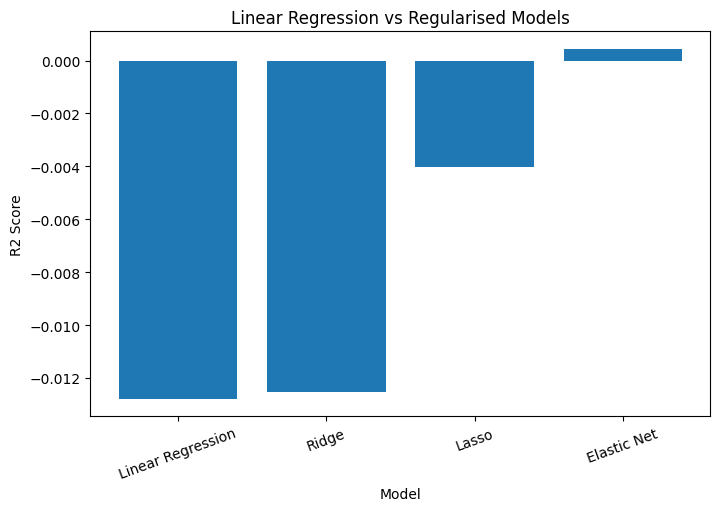


EXPERIMENT 4 COMPLETED


In [1]:
# EXPERIMENT 4
# Linear Regression and Regularisation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.metrics import mean_squared_error, r2_score


# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------

df = pd.read_csv("placement_dataset.csv")

print(df.head())


# --------------------------------------------------
# 2. Select Numerical Columns
# --------------------------------------------------

numeric_df = df.select_dtypes(
    include=["int64", "float64"]
).copy()

print("\nNUMERICAL COLUMNS")
print(numeric_df.columns.tolist())


# --------------------------------------------------
# 3. Select Target
# --------------------------------------------------

# Change this according to your dataset
target_column = "Salary"

if target_column not in numeric_df.columns:

    # Use last numerical column as target
    target_column = numeric_df.columns[-1]

print("\nTARGET COLUMN:", target_column)


# --------------------------------------------------
# 4. Prepare X and y
# --------------------------------------------------

X = numeric_df.drop(columns=[target_column])
y = numeric_df[target_column]


# --------------------------------------------------
# 5. Handle Missing Values
# --------------------------------------------------

X = X.fillna(X.median())
y = y.fillna(y.median())


# --------------------------------------------------
# 6. Train-Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# --------------------------------------------------
# 7. Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# --------------------------------------------------
# 8. Linear Regression
# --------------------------------------------------

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_prediction = linear_model.predict(X_test)

linear_mse = mean_squared_error(
    y_test,
    linear_prediction
)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)


# --------------------------------------------------
# 9. Ridge Regression
# --------------------------------------------------

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train,
    y_train
)

ridge_prediction = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(
    y_test,
    ridge_prediction
)

ridge_r2 = r2_score(
    y_test,
    ridge_prediction
)


# --------------------------------------------------
# 10. Lasso Regression
# --------------------------------------------------

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(
    X_train,
    y_train
)

lasso_prediction = lasso_model.predict(X_test)

lasso_mse = mean_squared_error(
    y_test,
    lasso_prediction
)

lasso_r2 = r2_score(
    y_test,
    lasso_prediction
)


# --------------------------------------------------
# 11. Elastic Net
# --------------------------------------------------

elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)

elastic_model.fit(
    X_train,
    y_train
)

elastic_prediction = elastic_model.predict(X_test)

elastic_mse = mean_squared_error(
    y_test,
    elastic_prediction
)

elastic_r2 = r2_score(
    y_test,
    elastic_prediction
)


# --------------------------------------------------
# 12. Display Results
# --------------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net"
    ],

    "MSE": [
        linear_mse,
        ridge_mse,
        lasso_mse,
        elastic_mse
    ],

    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ]
})

print("\nMODEL COMPARISON")
print(results)


# --------------------------------------------------
# 13. Plot R2 Scores
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Linear Regression vs Regularised Models")

plt.xticks(rotation=20)

plt.show()


print("\nEXPERIMENT 4 COMPLETED")